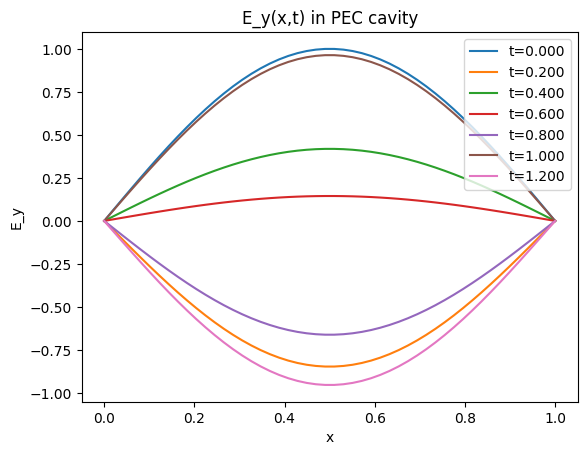

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
a = 1.0
eps = 1.0
mu = 1.0
c = 1 / np.sqrt(mu * eps)

Nx = 50
Nt = 500

dx = 0.005
dt = 0.5 * dx / c   # CFL condition

# Grids
x = np.linspace(0, a, Nx)

# Allocate matrices
E = np.zeros((Nt, Nx))
H = np.zeros((Nt, Nx))

# Initial condition: E(x,0) = sin(pi x / a)
E[0, :] = np.sin(np.pi * x / a)

# Time stepping
for n in range(Nt - 1):

    # --- Update H ---
    for i in range(Nx - 1):
        H[n+1, i] = H[n, i] + (dt / (mu * dx)) * (E[n, i+1] - E[n, i])

    # --- Update E ---
    for i in range(1, Nx - 1):
        E[n+1, i] = E[n, i] + (dt / (eps * dx)) * (H[n+1, i] - H[n+1, i-1])

    # --- PEC boundary conditions ---
    E[n+1, 0] = 0
    E[n+1, -1] = 0

# ---- Visualization ----

# Plot a few time snapshots
plt.figure()
for n in range(0, Nt, 80):
    plt.plot(x, E[n, :], label=f"t={n*dt:.3f}")
plt.title("E_y(x,t) in PEC cavity")
plt.xlabel("x")
plt.ylabel("E_y")
plt.legend()
plt.show()